# Chapter 3 Figures

## Kernel-Weight Method — Weight Diagnostic

Compares **OLD** (renorm + pooled gamma) vs **NEW** (raw CDF + core-point gamma)
weight computation for the KW MC correlation method.

Visual encoding:
- **Marker shape** = experiment
- **Color** = effective per-point weight (continuous colormap + colorbar)
- **Black edge** = core dataset (highest overlap weight per experiment)

In [1]:
from __future__ import annotations

import sys
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import norm

# Ensure kika is importable
REPO_ROOT = Path(r"C:\Users\Usuario\BaradDur\Dev\kika")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from kika.exfor import read_all_exfor

# ── Inline pipeline functions ──────────────────────────────────────────

def compute_overlap_weight(exp_energy_mev, sigma_E_mev, bin_lower_mev, bin_upper_mev):
    """CDF-based overlap weight: P(true energy in bin).  (exfor_utils.py:439-489)"""
    if sigma_E_mev <= 0:
        return 1.0 if bin_lower_mev <= exp_energy_mev <= bin_upper_mev else 0.0
    z_high = (bin_upper_mev - exp_energy_mev) / sigma_E_mev
    z_low = (bin_lower_mev - exp_energy_mev) / sigma_E_mev
    return norm.cdf(z_high) - norm.cdf(z_low)

# TOF sigma_E (tof_parameters.py:163-217)
NEUTRON_MASS_MEV = 939.565378
SPEED_OF_LIGHT_M_NS = 0.299792458

def compute_sigma_E(energy_mev, flight_path_m, time_resolution_ns, min_sigma_E_kev=1.0):
    """Compute energy resolution sigma_E from TOF parameters."""
    if energy_mev <= 0:
        return min_sigma_E_kev / 1000.0
    velocity_m_ns = SPEED_OF_LIGHT_M_NS * np.sqrt(2.0 * energy_mev / NEUTRON_MASS_MEV)
    flight_time_ns = flight_path_m / velocity_m_ns
    sigma_E_mev = energy_mev * 2.0 * (time_resolution_ns / flight_time_ns)
    return max(sigma_E_mev, min_sigma_E_kev / 1000.0)

def get_full_subentry_id(obj):
    """Get the full EXFOR subentry ID (e.g., '10571002').
    Handles both DB format (entry='10571', subentry='002')
    and JSON format (entry='27673', subentry='27673002')."""
    if obj.subentry.startswith(obj.entry):
        return obj.subentry
    return f"{obj.entry}{obj.subentry}"

# ── Constants ──────────────────────────────────────────────────────────

MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CMAP = plt.cm.plasma

# Data paths
DB_PATH = r"c:\Users\Usuario\BaradDur\EXFOR\x4sqlite-20251105-c\x4sqlite1.db"
SUPPLEMENTARY_JSON = r"c:\Users\Usuario\BaradDur\EXFOR\data_v1\data_v1\27673002.json"
TOF_FILE = Path(r"c:\Users\Usuario\BaradDur\EXFOR\exfor_tof_parameters.json")

# Pipeline grid config (exfor_to_endf_sampling_v2.py:378-383)
UNION_GRID_SUBENTRIES = [
    ("10571002", 0.847, 2.5),   # Kinney
    ("10886002", 2.5, 4.0),     # Smith
]
ENERGY_MIN, ENERGY_MAX = 0.847, 4.0
EXCLUDED = {"32246002"}
MIN_WEIGHT = 1e-3

# Weight parameters (matching pipeline config)
WEIGHT_GAMMA = 0.5
MAX_EXP_WEIGHT_FRAC_OLD = 0.50   # Old cap
MAX_EXP_WEIGHT_FRAC_NEW = 0.80   # New cap

# Default TOF params (ORELA-like)
DEFAULT_L = 27.037
DEFAULT_DT = 5.0

# Manuscript figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

## 1. Load EXFOR data and TOF parameters

In [2]:
# Load EXFOR angular distribution data from X4Pro database + supplementary JSON
# Uses target_zaid=[26056, 26000] to include both Fe-56 and natural iron (Fe-0)
# This matches the pipeline config (exfor_to_endf_sampling_v2.py:175)
exfor_dict = read_all_exfor(
    source="database",
    db_path=DB_PATH,
    supplementary_json_files=[SUPPLEMENTARY_JSON],
    group_by_energy=False,
    target_zaid=[26056, 26000],
    projectile="N",
    mt=2,
)
exfor_objects = list(exfor_dict.values())
print(f"Loaded {len(exfor_objects)} EXFOR datasets")

# Build label lookup and TOF params per experiment
label_map = {}   # exp_id -> "Author et al. (Year)"
tof_map = {}     # full_subentry_id -> (flight_path_m, time_resolution_ns)

with open(TOF_FILE) as f:
    tof_raw = json.load(f)

for obj in exfor_objects:
    subentry_id = get_full_subentry_id(obj)
    exp_id = f"{obj.entry}.{subentry_id}"
    label_map[exp_id] = obj.label

    if subentry_id not in tof_map:
        entry_data = tof_raw.get(subentry_id, {})
        eri = entry_data.get("energy_resolution_input") or entry_data.get("energy_resolution_inputs") or {}
        L = eri.get("distance", {}).get("value")
        dt = eri.get("time_resolution", {}).get("value")
        tof_map[subentry_id] = (
            float(L) if L is not None else DEFAULT_L,
            float(dt) if dt is not None else DEFAULT_DT,
        )

# Build the energy -> datasets cache from ExforAngularDistribution objects
exfor_cache = defaultdict(list)  # energy_mev -> [dataset_dict, ...]

for obj in exfor_objects:
    subentry_id = get_full_subentry_id(obj)
    if subentry_id in EXCLUDED:
        continue
    exp_id = f"{obj.entry}.{subentry_id}"
    for energy_mev in obj.energies(unit="MeV"):
        df = obj.to_dataframe(
            energy=energy_mev, energy_unit="MeV",
            cross_section_unit="b/sr", angle_unit="deg",
            tolerance=1e-4,
        )
        if df.empty:
            continue
        exfor_cache[energy_mev].append({
            "exp_id": exp_id,
            "subentry_id": subentry_id,
            "angle": df["angle"].values,
            "dsig": df["value"].values,
            "error": df["error"].values,
            "frame": obj.angle_frame,
        })

sorted_energies = sorted(exfor_cache.keys())
print(f"Cache: {len(sorted_energies)} unique energies "
      f"[{sorted_energies[0]:.4f}, {sorted_energies[-1]:.4f}] MeV")
print(f"TOF params for {len(tof_map)} experiments")

# Show loaded datasets for verification
print(f"\nDatasets loaded:")
for obj in sorted(exfor_objects, key=lambda o: o.label):
    sid = get_full_subentry_id(obj)
    n_e = len(obj.energies(unit="MeV"))
    e_range = obj.energies(unit="MeV")
    print(f"  {sid:12s}  {obj.label:30s}  n_E={n_e:5d}  E=[{min(e_range):.4f}, {max(e_range):.4f}] MeV")

Loaded 120 EXFOR datasets
Cache: 22687 unique energies [0.0350, 96.0000] MeV
TOF params for 120 experiments

Datasets loaded:
  11716002      Anderson (1958)                 n_E=    1  E=[14.6000, 14.6000] MeV
  22480004      Baba (2002)                     n_E=    3  E=[55.0000, 75.0000] MeV
  30076004      Barnard (1968)                  n_E=   95  E=[0.9400, 1.1800] MeV
  11511009      Becker (1966)                   n_E=    1  E=[3.2000, 3.2000] MeV
  21664010      Begum (1979)                    n_E=    1  E=[16.1000, 16.1000] MeV
  30633002      Begum (1981)                    n_E=    1  E=[2.9000, 2.9000] MeV
  11220013      Beyster (1956)                  n_E=    2  E=[2.5000, 7.0000] MeV
  10037024      Boschung (1971)                 n_E=    2  E=[5.0500, 5.5800] MeV
  11341005      Bostrom (1959)                  n_E=    3  E=[3.6700, 4.7000] MeV
  11496004      Bredin (1964)                   n_E=    1  E=[1.9500, 1.9500] MeV
  10556006      Bucher (1975)                   

## 2. Build union energy grid and bin boundaries (pipeline-equivalent)

In [3]:
# Replicate build_union_energy_grid() (exfor_utils.py:620-687)
# Union grid: Kinney energies in [0.847, 2.5] + Smith energies in [2.5, 4.0]
union_energies = set()
for energy_mev, entries in exfor_cache.items():
    for ds in entries:
        sid = ds["subentry_id"]
        for sub_id, lo, hi in UNION_GRID_SUBENTRIES:
            if sid == sub_id and lo <= energy_mev <= hi:
                union_energies.add(energy_mev)

union_energies.update([ENERGY_MIN, ENERGY_MAX])
grid = np.array(sorted(union_energies))
print(f"Union grid: {len(grid)} points [{grid[0]:.4f}, {grid[-1]:.4f}] MeV")

# Replicate compute_energy_bins_with_tof_resolution() bin boundaries
# (exfor_utils.py:560-602): midpoints between consecutive grid points
bin_boundaries = []  # list of (energy, lo, hi)
n = len(grid)
for i, e in enumerate(grid):
    if i == 0:
        if n > 1:
            half_width = (grid[1] - e) / 2.0
            lo = max(0.0, e - half_width)
        else:
            lo = 0.0
    else:
        lo = (grid[i - 1] + e) / 2.0

    if i == n - 1:
        hi = e + (e - lo)
    else:
        hi = (e + grid[i + 1]) / 2.0

    bin_boundaries.append((e, lo, hi))

print(f"Bin boundaries computed for {len(bin_boundaries)} bins")
# Show a few examples
for idx in [0, 1, len(bin_boundaries) // 2, -1]:
    e, lo, hi = bin_boundaries[idx]
    print(f"  [{idx:4d}] E={e:.4f} MeV  bin=[{lo:.4f}, {hi:.4f}]")

Union grid: 1683 points [0.8470, 4.0000] MeV
Bin boundaries computed for 1683 bins
  [   0] E=0.8470 MeV  bin=[0.8465, 0.8475]
  [   1] E=0.8480 MeV  bin=[0.8475, 0.8485]
  [ 841] E=1.6880 MeV  bin=[1.6875, 1.6885]
  [  -1] E=4.0000 MeV  bin=[3.9525, 4.0475]


## 3. Compute OLD vs NEW weights for a target energy bin

**OLD** (current pipeline): CDF overlap → experiment-level renormalization (`scale = max_w / sum_w`) → gamma with pooled `n_study` (all energies)

**NEW** (proposed): CDF overlap (raw) → gamma with core-point `n_core` (closest energy only)

In [ ]:
TARGET_ENERGIES = [0.85, 1.0, 1.30, 1.5, 1.8, 2.15, 2.5, 3.5]

# Pipeline uncertainty floor config (exfor_to_endf_sampling_v2.py:329-331)
MIN_RELATIVE_UNCERTAINTY = 0.05  # 5% floor
UNC_FLOOR_STRATEGY = "bin_median"

def apply_unc_floor_bin_median(datasets, min_rel_unc=0.05):
    """Apply bin_median uncertainty floor.
    Replicates exfor_utils.py:1252-1377 apply_uncertainty_floor exactly."""
    # Collect all (value, unc) pairs across all datasets
    all_values = np.concatenate([d["dsig"] for d in datasets])
    all_errors = np.concatenate([d["error"] for d in datasets])

    # Pipeline logic (exfor_utils.py:1299-1301): use abs_val_safe to avoid div/0
    abs_val = np.abs(all_values).astype(float)
    abs_val_safe = np.maximum(abs_val, 1e-30)
    rel_unc = all_errors.astype(float) / abs_val_safe

    # Identify points below threshold
    below = rel_unc < min_rel_unc
    if not np.any(below):
        return datasets, 0.0, 0

    # Trustworthy points: above threshold
    trustworthy = ~below
    if np.sum(trustworthy) >= 3:
        replacement_rel = float(np.nanmedian(rel_unc[trustworthy]))
        if np.isnan(replacement_rel):
            replacement_rel = min_rel_unc
    else:
        replacement_rel = min_rel_unc

    # Apply replacement: replacement_abs = replacement_rel * abs_val (NOT abs_val_safe)
    # This matches pipeline line 1333: replacement_abs = replacement_rel * abs_val
    replacement_abs_all = replacement_rel * abs_val

    # Apply per dataset
    floored_datasets = []
    n_floored_total = 0
    offset = 0
    for d in datasets:
        d_new = dict(d)
        n = len(d["dsig"])
        error = d["error"].copy().astype(float)
        below_slice = below[offset:offset + n]
        repl_slice = replacement_abs_all[offset:offset + n]
        n_floored_total += int(np.sum(below_slice))
        error[below_slice] = repl_slice[below_slice]
        d_new["error"] = error
        floored_datasets.append(d_new)
        offset += n

    return floored_datasets, replacement_rel, n_floored_total


def compute_weights_for_bin(target_energy_mev, grid, bin_boundaries, exfor_cache, tof_map,
                            label_map, min_weight=MIN_WEIGHT, gamma=WEIGHT_GAMMA,
                            apply_unc_floor=True):
    """Compute OLD and NEW weights for a single energy bin."""
    idx = np.argmin(np.abs(grid - target_energy_mev))
    bin_energy, bin_lo, bin_hi = bin_boundaries[idx]

    # Collect ALL datasets with raw CDF overlap weight
    raw_datasets = []
    for energy_mev, entries in exfor_cache.items():
        for ds in entries:
            L, dt = tof_map.get(ds["subentry_id"], (DEFAULT_L, DEFAULT_DT))
            sigma_E = compute_sigma_E(energy_mev, L, dt)
            w = compute_overlap_weight(energy_mev, sigma_E, bin_lo, bin_hi)
            if w >= min_weight:
                raw_datasets.append({
                    **ds,
                    "energy_mev": energy_mev,
                    "weight_raw": w,
                    "sigma_E": sigma_E,
                    "n_angular": len(ds["angle"]),
                })

    # Apply uncertainty floor (matching pipeline behavior)
    floor_rel = 0.0
    n_floored = 0
    if apply_unc_floor and raw_datasets:
        raw_datasets, floor_rel, n_floored = apply_unc_floor_bin_median(
            raw_datasets, MIN_RELATIVE_UNCERTAINTY)

    # Group by experiment
    exp_groups = defaultdict(list)
    for i, ds in enumerate(raw_datasets):
        exp_groups[ds["exp_id"]].append(i)

    # Compute OLD + NEW weights
    old_datasets = []
    new_datasets = []
    for exp_id, indices in exp_groups.items():
        raw_weights = [raw_datasets[i]["weight_raw"] for i in indices]
        max_w = max(raw_weights)
        sum_w = sum(raw_weights)
        renorm_scale = max_w / sum_w

        core_idx = max(indices, key=lambda i: raw_datasets[i]["weight_raw"])
        n_core = raw_datasets[core_idx]["n_angular"]
        n_pool = sum(raw_datasets[i]["n_angular"] for i in indices)

        for i in indices:
            is_core = (i == core_idx)
            base = dict(raw_datasets[i])
            base["is_core"] = is_core

            ds_old = dict(base)
            ds_old["weight_renorm"] = ds_old["weight_raw"] * renorm_scale
            ds_old["n_pool"] = n_pool
            ds_old["old_ppw"] = ds_old["weight_renorm"] * (n_pool ** (gamma - 1.0))
            old_datasets.append(ds_old)

            ds_new = dict(base)
            ds_new["n_core"] = n_core
            ds_new["new_ppw"] = ds_new["weight_raw"] * (n_core ** (gamma - 1.0))
            new_datasets.append(ds_new)

    return {
        "target": target_energy_mev,
        "bin_energy": bin_energy,
        "bin_lo": bin_lo,
        "bin_hi": bin_hi,
        "raw_datasets": raw_datasets,
        "old_datasets": old_datasets,
        "new_datasets": new_datasets,
        "exp_groups": exp_groups,
        "exp_ids": sorted(exp_groups.keys()),
        "floor_rel": floor_rel,
        "n_floored": n_floored,
    }


def compute_wls_fractions(datasets, weight_key, exp_ids):
    """Compute WLS effective fractions using real (floored) uncertainties.
    WLS effective weight per point = kernel_weight / sigma^2.
    Matches pipeline: exfor_utils.py:1425-1426 and 1828-1829."""
    all_wls = []
    all_exp = []
    for d in datasets:
        sigma = d["error"].astype(float)
        # Pipeline uses np.maximum(sigma, 1e-30) but that creates inf for zero-error pts.
        # Skip points where sigma is effectively zero (no information).
        valid = sigma > 1e-10
        if not np.any(valid):
            continue
        wls_per_point = np.zeros(len(sigma))
        wls_per_point[valid] = d[weight_key] / (sigma[valid] ** 2)
        all_wls.append(wls_per_point)
        all_exp.append(np.full(len(sigma), d["exp_id"]))

    if not all_wls:
        return {}

    wls_arr = np.concatenate(all_wls)
    exp_arr = np.concatenate(all_exp)
    total_wls = wls_arr.sum()

    fracs = {}
    for eid in exp_ids:
        mask = exp_arr == eid
        fracs[eid] = float(wls_arr[mask].sum() / total_wls) if total_wls > 0 else 0.0
    return fracs


# ── Run for all target energies ──
for target_E in TARGET_ENERGIES:
    diag = compute_weights_for_bin(target_E, grid, bin_boundaries, exfor_cache, tof_map, label_map)
    bin_energy = diag["bin_energy"]
    bin_lo, bin_hi = diag["bin_lo"], diag["bin_hi"]
    old_datasets = diag["old_datasets"]
    new_datasets = diag["new_datasets"]
    exp_ids_bin = diag["exp_ids"]

    print(f"\n{'='*140}")
    print(f"E_target={target_E:.2f} MeV -> grid E={bin_energy:.4f}, bin=[{bin_lo:.4f}, {bin_hi:.4f}], "
          f"width={1e3*(bin_hi-bin_lo):.2f} keV, "
          f"n_datasets={len(old_datasets)}, n_exp={len(exp_ids_bin)}")
    print(f"Unc floor: {diag['n_floored']} points floored to median_rel={diag['floor_rel']:.3f} "
          f"({diag['floor_rel']*100:.1f}%)")
    print(f"{'='*140}")
    print(f"{'Experiment':<30s} | {'n_E':>4s} | {'n_core':>6s} | {'sigE_k':>7s} | "
          f"{'OLD_npool':>9s} | {'OLD_wcore':>10s} | {'OLD_ppw':>10s} | "
          f"{'NEW_wcore':>10s} | {'NEW_ppw':>10s} | {'ratio':>7s}")
    print(f"{'-'*30}-+-{'-'*4}-+-{'-'*6}-+-{'-'*7}-+-"
          f"{'-'*9}-+-{'-'*10}-+-{'-'*10}-+-"
          f"{'-'*10}-+-{'-'*10}-+-{'-'*7}")

    for exp_id in exp_ids_bin:
        old_exp = [d for d in old_datasets if d["exp_id"] == exp_id]
        new_exp = [d for d in new_datasets if d["exp_id"] == exp_id]
        n_energies = len(old_exp)

        old_core = [d for d in old_exp if d["is_core"]][0]
        new_core = [d for d in new_exp if d["is_core"]][0]

        label = label_map.get(exp_id, exp_id)[:30]
        ratio = new_core["new_ppw"] / old_core["old_ppw"] if old_core["old_ppw"] > 1e-30 else float('inf')

        print(f"{label:<30s} | {n_energies:4d} | {new_core['n_core']:6d} | "
              f"{old_core['sigma_E']*1e3:6.1f}k | "
              f"{old_core['n_pool']:9d} | {old_core['weight_renorm']:10.6f} | {old_core['old_ppw']:10.6f} | "
              f"{new_core['weight_raw']:10.6f} | {new_core['new_ppw']:10.6f} | {ratio:6.1f}x")

    # WLS fractions with real (floored) uncertainties
    old_wls = compute_wls_fractions(old_datasets, "old_ppw", exp_ids_bin)
    new_wls = compute_wls_fractions(new_datasets, "new_ppw", exp_ids_bin)

    print(f"\n  WLS fractions (with {MIN_RELATIVE_UNCERTAINTY*100:.0f}% uncertainty floor):")
    print(f"  {'Experiment':<28s} | {'OLD_wls':>9s} | {'NEW_wls':>9s} | {'cap@80%':>8s}")
    print(f"  {'-'*28}-+-{'-'*9}-+-{'-'*9}-+-{'-'*8}")
    for exp_id in exp_ids_bin:
        label = label_map.get(exp_id, exp_id)[:28]
        old_f = old_wls.get(exp_id, 0)
        new_f = new_wls.get(exp_id, 0)
        cap_flag = " *** CAP" if new_f > 0.80 else ""
        print(f"  {label:<28s} | {old_f:8.1%} | {new_f:8.1%} |{cap_flag}")

## 4. Plot: NEW effective per-point weights at E = 1.8 MeV

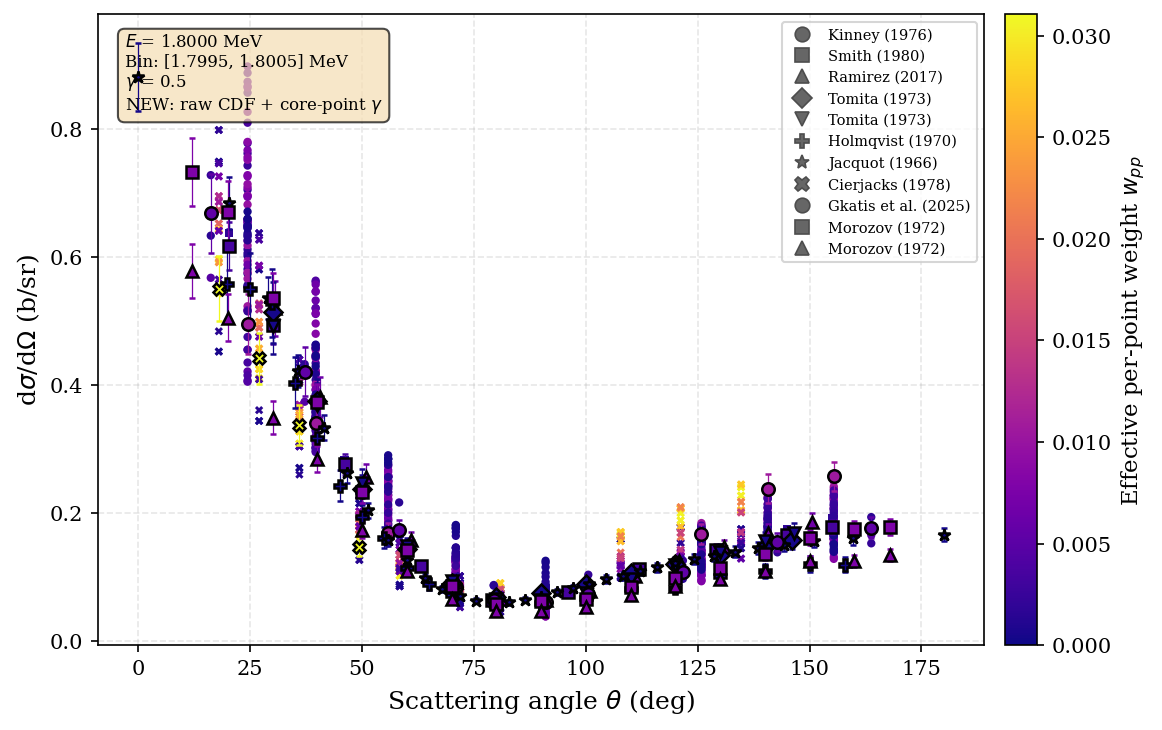

In [5]:
# Compute for E=1.8 MeV for the plot
diag_plot = compute_weights_for_bin(1.8, grid, bin_boundaries, exfor_cache, tof_map, label_map)
new_ds = diag_plot["new_datasets"]
exp_ids_plot = diag_plot["exp_ids"]
bin_energy = diag_plot["bin_energy"]
bin_lo, bin_hi = diag_plot["bin_lo"], diag_plot["bin_hi"]

fig, ax = plt.subplots(figsize=(8, 5))

all_ppw = [d["new_ppw"] for d in new_ds]
w_norm = mcolors.Normalize(vmin=0, vmax=max(all_ppw))
sm = cm.ScalarMappable(cmap=CMAP, norm=w_norm)
sm.set_array([])

exp_marker = {eid: MARKERS[i % len(MARKERS)] for i, eid in enumerate(exp_ids_plot)}

for eid in exp_ids_plot:
    marker = exp_marker[eid]
    ds_list = [d for d in new_ds if d["exp_id"] == eid]

    non_core = [d for d in ds_list if not d["is_core"]]
    if non_core:
        angles = np.concatenate([d["angle"] for d in non_core])
        values = np.concatenate([d["dsig"] for d in non_core])
        colors = np.concatenate([
            np.full(len(d["angle"]), d["new_ppw"]) for d in non_core
        ])
        ax.scatter(
            angles, values,
            c=CMAP(w_norm(colors)),
            marker=marker, s=16,
            edgecolors="none", linewidths=0.3,
            zorder=2,
        )

    core = [d for d in ds_list if d["is_core"]]
    for d in core:
        color = CMAP(w_norm(d["new_ppw"]))
        ax.errorbar(
            d["angle"], d["dsig"],
            yerr=d["error"],
            fmt=marker,
            color=color,
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=6.0,
            capsize=1.5, capthick=0.6, elinewidth=0.6,
            ecolor=color,
            zorder=4,
            label="_nolegend_",
        )

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Effective per-point weight $w_{pp}$", fontsize=11)

legend_handles = []
for eid in exp_ids_plot:
    marker = exp_marker[eid]
    label = label_map.get(eid, eid)
    handle = Line2D(
        [0], [0], marker=marker, color="none",
        markerfacecolor="0.4", markeredgecolor="0.3",
        markersize=7, markeredgewidth=0.8, label=label,
    )
    legend_handles.append(handle)

ax.legend(handles=legend_handles, loc="upper right", frameon=True,
          fancybox=True, fontsize=7, ncol=1)

ax.set_xlabel(r"Scattering angle $\theta$ (deg)")
ax.set_ylabel(r"d$\sigma$/d$\Omega$ (b/sr)")

textstr = (f"$E$ = {bin_energy:.4f} MeV\n"
           f"Bin: [{bin_lo:.4f}, {bin_hi:.4f}] MeV\n"
           f"$\\gamma$ = {WEIGHT_GAMMA}\n"
           f"NEW: raw CDF + core-point $\\gamma$")
props = dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7)
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment="top", horizontalalignment="left", bbox=props)

plt.tight_layout()
plt.show()